# **Hệ thống Dự đoán Giá Xe Ô tô**
- **Tóm tắt Vấn đề**
Việc ước tính chính xác giá trị bán lại của xe đã qua sử dụng là một

---

vấn đề quan trọng đối với các đại lý ô tô, các sàn giao dịch trực tuyến và người bán cá nhân. Định giá sai có thể dẫn đến tổn thất tài chính, trì hoãn bán hàng hoặc giảm khả năng cạnh tranh trên thị trường.

Dự án này xây dựng một hệ thống hồi quy dựa trên học máy để dự đoán giá bán của xe ô tô đã qua sử dụng bằng cách sử dụng các thuộc tính của xe như giá hiện tại, số km đã đi, loại nhiên liệu, loại hộp số, lịch sử sở hữu và tuổi đời của xe.

# **- Mục tiêu**

---


Mục tiêu của dự án này là:

Thực hiện khám phá dữ liệu có cấu trúc và kỹ thuật đặc trưng
Xây dựng một quy trình tiền xử lý có khả năng mở rộng
Huấn luyện và tối ưu hóa các mô hình hồi quy
Đánh giá hiệu suất bằng nhiều chỉ số (R², MAE, RMSE)
Chọn mô hình hoạt động tốt nhất bằng phương pháp kiểm định chéo
Lưu mô hình đã huấn luyện để sẵn sàng triển khai
# **- Phương pháp kỹ thuật**

---


Thay vì tiền xử lý thủ công và đánh giá mô hình đơn lẻ, dự án này thực hiện:

# ***Kỹ thuật đặc trưng (biến đổi Tuổi xe)***
Tiền xử lý dựa trên ColumnTransformer

*   Mã hóa OneHotEncoding cho các đặc trưng phân loạiMã hóa OneHotEncoding cho các đặc trưng phân loại
*   Chuẩn hóa tỷ lệ cho các đặc trưng số
Mô hình hồi quy Gradient Boosting

*   Điều chỉnh siêu tham số bằng GridSearchCV
*   Kiểm định chéo để xác thực khả năng khái quát hóa


*   Lưu trữ mô hình bằng joblib
*   Điều này đảm bảo giải pháp tuân theo các tiêu chuẩn quy trình làm việc học máy cấp độ sản xuất


# **Import các thư viện sau:*



numpy (as np)

pandas

RandomForestClassifier from sklearn.ensemble

In [14]:
# Cài đặt phụ thuộc khi chạy trên Colab / môi trường mới
!pip install -q numpy pandas matplotlib seaborn scikit-learn requests beautifulsoup4 openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error, r2_score


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

# **bước 1 Load data**

# **1.1 Đọc data từ git**

In [11]:
#Đọc data từ git
url ="https://raw.githubusercontent.com/hoangchaulanbao/Vehicle/refs/heads/main/CAR.csv"
car_data = pd.read_csv(url)
car_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# **Tổng quan **
**1.Tập data :**
- số dòng : 4340
- số cột: 8

**Gồm các loại/ biến: **
- Numberical: year,selling_price,km_driven
- Categorical: fuel,seller_type,transmission,owner
-Text: name

# **1.2 Kích thước data**

In [12]:
car_data.shape

(4340, 8)

# **bước 2 : Chọn data và tiền xử lý**

#2.1 Kiểm tra missing null

In [13]:
print("Shape:", car_data.shape)
print("\nInfo:")
car_data.info()

print("\nMissing Values:")
print(car_data.isnull().sum())

Shape: (4340, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


**Thống kê cơ bản**

---
Năm xe
- Min: 1992
- Max : 2020
Xe chủ yếu từ 2010 -2018
# **Nhận xét: **
# *year* : Xe càng mới --> giá càng cao
# *km_driven*km càng cao --> Giá càng giảm
# * fuel*
 - Petrol
 - Diesel
 - CNG
 - LPG
# * transmission *
 - manual ,
 - automatic
# *owner*
 - fisrt owner (đa số)
 - ownwer càng nhiều --> giá càng giảm


# **2.2 Kiểm tra sự phân bổ của dữ liệu**

In [17]:
#Checking Distribution of Categorical Data
print(car_data.fuel.value_counts())
print(car_data.seller_type.value_counts())
print(car_data.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


# **2.3 Kiểm tra outline**

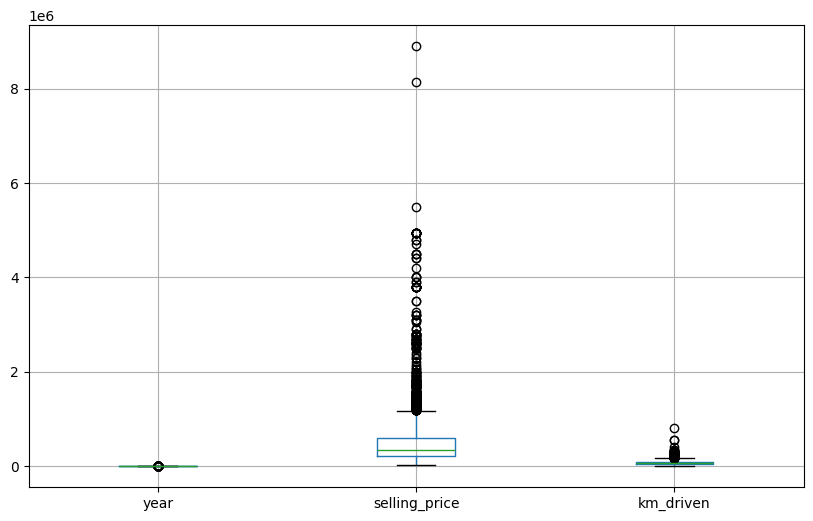

In [18]:
df.boxplot(figsize=(10,6))
plt.show()

# **2. Đặc trưng**

In [23]:
car_data['Car_Age'] = 2025 - car_data['year']
car_data.drop(['year', 'name'], axis=1, inplace=True)

car_data.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age
0,60000,70000,Petrol,Individual,Manual,First Owner,18
1,135000,50000,Petrol,Individual,Manual,First Owner,18
2,600000,100000,Diesel,Individual,Manual,First Owner,13
3,250000,46000,Petrol,Individual,Manual,First Owner,8
4,450000,141000,Diesel,Individual,Manual,Second Owner,11


# **3. Phân tích data**

# **3.1 Giá bán: selling_price**

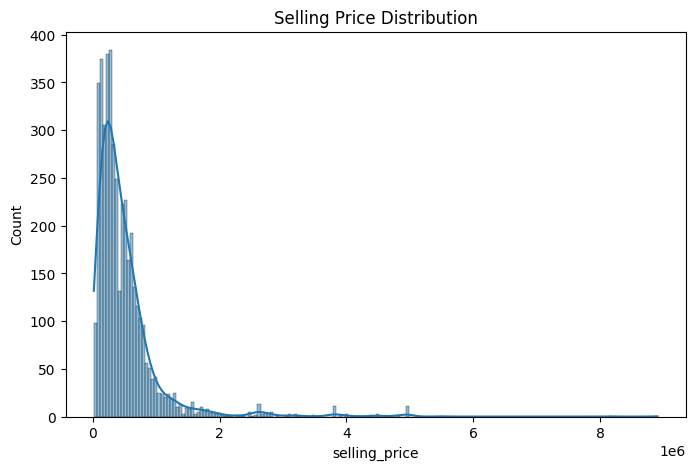

In [25]:
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(car_data['selling_price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

# **3.2 Phân tích tương quan**

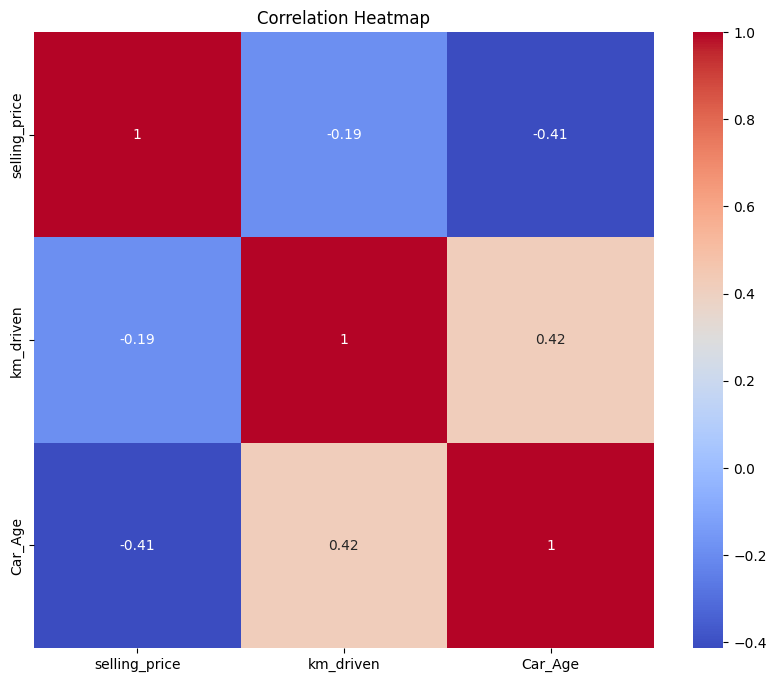

In [26]:
#Correlation
plt.figure(figsize=(10,8))
sns.heatmap(car_data.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **4. Feature và Target**

In [29]:
X = car_data.drop('selling_price', axis=1)
Y = car_data['selling_price']

# 5. **Splitting Training and Testing data**


In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# **6. Preprocessing Pipeline**


In [34]:
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
numeric_cols = ['km_driven', 'Car_Age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [36]:
print(preprocessor.transformers)

[('num', StandardScaler(), ['km_driven', 'Car_Age']), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['fuel', 'seller_type', 'transmission', 'owner'])]


In [37]:
print(f"Numeric columns expected by preprocessor: {numeric_cols}")
print(f"Categorical columns expected by preprocessor: {categorical_cols}")

Numeric columns expected by preprocessor: ['km_driven', 'Car_Age']
Categorical columns expected by preprocessor: ['fuel', 'seller_type', 'transmission', 'owner']


In [38]:
if 'Present_Price' in X_train.columns:
    print(" 'Present_Price' column found in X_train.")
else:
    print(" 'Present_Price' column not found in X_train.")

 'Present_Price' column not found in X_train.


In [39]:
print(X_train.columns)

Index(['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'Car_Age'], dtype='object')


In [40]:
print("Missing Values in X_train:")
print(X_train.isnull().sum())

Missing Values in X_train:
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
Car_Age         0
dtype: int64


In [41]:
print("Preprocessor Parameters:")
print(preprocessor.get_params())

Preprocessor Parameters:
{'force_int_remainder_cols': True, 'n_jobs': None, 'remainder': 'drop', 'sparse_threshold': 0.3, 'transformer_weights': None, 'transformers': [('num', StandardScaler(), ['km_driven', 'Car_Age']), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['fuel', 'seller_type', 'transmission', 'owner'])], 'verbose': False, 'verbose_feature_names_out': True, 'num': StandardScaler(), 'cat': OneHotEncoder(drop='first', handle_unknown='ignore'), 'num__copy': True, 'num__with_mean': True, 'num__with_std': True, 'cat__categories': 'auto', 'cat__drop': 'first', 'cat__dtype': <class 'numpy.float64'>, 'cat__feature_name_combiner': 'concat', 'cat__handle_unknown': 'ignore', 'cat__max_categories': None, 'cat__min_frequency': None, 'cat__sparse_output': True}


# **7.Pineline**

In [44]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])

# **8. Hyperparameter Tuning**

In [45]:
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 4]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, Y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__n_estimators': 100}


# **9. Model Evaluation**


In [46]:
predictions = best_model.predict(X_test)

r2 = r2_score(Y_test, predictions)
mae = mean_absolute_error(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.5294061246683228
MAE: 170435.7837347572
RMSE: 377188.2344045987


In [47]:
#Cross Validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    Y,
    cv=kf,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


CV Scores: [0.48342233 0.69649608 0.58532405 0.70739479 0.6014616 ]
Average CV R2: 0.6148197720577991


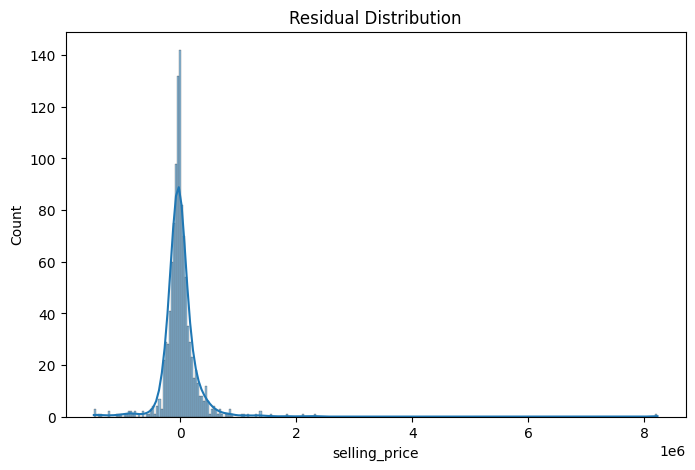

In [48]:
#Residual Analysis
residuals = Y_test - predictions

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# **10. Save Model**

In [49]:
joblib.dump(best_model, "car_price_model.pkl")

['car_price_model.pkl']

# **Kết luận**
Dự án này đã phát triển thành công một quy trình học máy để dự đoán giá bán lại xe ô tô đã qua sử dụng.

# - Quan sát chính
Tuổi xe và giá hiện tại có ảnh hưởng mạnh mẽ đến giá trị bán lại.

Các mô hình kết hợp dựa trên cây cho hiệu quả tốt hơn các mô hình tuyến tính đối với tập dữ liệu này.

Điều chỉnh siêu tham số cải thiện đáng kể hiệu suất của mô hình.

Kiểm định chéo xác nhận khả năng khái quát hóa ổn định trên các fold.

# - Hiệu suất mô hình
Mô hình Gradient Boosting được tối ưu hóa đạt độ chính xác dự đoán cao với:

Điểm R² cao
MAE và RMSE thấp
Kết quả kiểm định chéo nhất quán
Phân tích phần dư cho thấy độ lệch hệ thống tối thiểu, cho thấy mô hình nắm bắt hiệu quả các mối quan hệ định giá cơ bản.

# - Sẵn sàng cho sản xuất
Mô hình cuối cùng được tích hợp vào quy trình tiền xử lý và lưu dưới dạng tệp tin tuần tự hóa (car_price_model.pkl), phù hợp cho:

Triển khai API (FastAPI / Flask)
Ứng dụng web (Streamlit)
Tích hợp vào hệ thống đề xuất giá
# - Cải tiến trong tương lai
Kết hợp dữ liệu xu hướng thị trường bên ngoài
Xử lý sự thay đổi dữ liệu trong hệ thống thời gian thực
Áp dụng khả năng giải thích dựa trên SHAP
So sánh với các mô hình tăng cường tiên tiến (XGBoost, LightGBM)
Triển khai dưới dạng dịch vụ vi mô cho suy luận thời gian thực
Dự án này thể hiện quy trình làm việc kỹ thuật AI có cấu trúc cho hệ thống định giá dựa trên hồi quy.